In [1]:
from prody import *
confProDy(verbosity='warning')
import numpy as np

# --- Fix: QDNP015.pdb has non-standard residue numbers (ViNAS format quirk)
# --- We rewrite residue numbers sequentially before parsing with ProDy
with open('pdb_files/QDNP015.pdb') as f:
    raw_lines = f.readlines()

fixed_lines = []
resnum = 1
for line in raw_lines:
    if line.startswith('ATOM') or line.startswith('HETATM'):
        line = line[:22] + f'{resnum:4d}' + ' ' + line[27:]
        resnum = resnum + 1 if resnum < 9999 else 1
    fixed_lines.append(line)

with open('pdb_files/QDNP015_fixed.pdb', 'w') as f:
    f.writelines(fixed_lines)

# 1. Load fixed PDB file
structure = parsePDB('pdb_files/QDNP015_fixed.pdb')
print(f'Loaded structure: {structure.numAtoms()} total atoms')

# 2. Coarse-grain: select ONLY Cadmium atoms as GNM nodes
# Note: QDNP015 is a CdTe QD — element label in PDB is 'CD' (not 'Cd')
nodes = structure.select('element CD')
print(f'Selected Cd nodes: {nodes.numAtoms()}')

# 3. Initialize the GNM
gnm = GNM('QDNP015_GNM')

# 4. Build the Kirchhoff matrix using 6.0 Å cutoff
gnm.buildKirchhoff(nodes, cutoff=6.0)
print(f'Kirchhoff matrix shape: {gnm.getKirchhoff().shape}')

# 5. Calculate the modes (eigenvalues and eigenvectors)
gnm.calcModes()

# 6. Get the eigenvalues
eigenvalues = gnm.getEigvals()
print(f'\nNumber of calculated eigenvalues: {len(eigenvalues)}')
print('\nAll eigenvalues (non-trivial modes):')
for i, ev in enumerate(eigenvalues):
    print(f'  Mode {i+1}: λ = {ev:.6f}')

print(f'\nSlowest (softest) mode  λ₁ = {eigenvalues[0]:.6f}')
print(f'Fastest mode  λ{len(eigenvalues)} = {eigenvalues[-1]:.6f}')

Loaded structure: 2805 total atoms
Selected Cd nodes: 902
Kirchhoff matrix shape: (902, 902)

Number of calculated eigenvalues: 20

All eigenvalues (non-trivial modes):
  Mode 1: λ = 0.274187
  Mode 2: λ = 0.274187
  Mode 3: λ = 0.290796
  Mode 4: λ = 0.667726
  Mode 5: λ = 0.667726
  Mode 6: λ = 0.693327
  Mode 7: λ = 0.706493
  Mode 8: λ = 0.706493
  Mode 9: λ = 1.078119
  Mode 10: λ = 1.174612
  Mode 11: λ = 1.174612
  Mode 12: λ = 1.218493
  Mode 13: λ = 1.218493
  Mode 14: λ = 1.257758
  Mode 15: λ = 1.265606
  Mode 16: λ = 1.354760
  Mode 17: λ = 1.668824
  Mode 18: λ = 1.703402
  Mode 19: λ = 1.703402
  Mode 20: λ = 1.750663

Slowest (softest) mode  λ₁ = 0.274187
Fastest mode  λ20 = 1.750663


In [2]:
import matplotlib.pyplot as plt
import matplotlib

print(f'matplotlib version: {matplotlib.__version__}')

matplotlib version: 3.9.4


In [3]:
from prody import *
confProDy(verbosity='warning')
import numpy as np

# --- Fix: QDNP015.pdb has non-standard residue numbers (ViNAS format quirk)
# --- We rewrite residue numbers sequentially before parsing with ProDy
with open('pdb_files/QDNP015.pdb') as f:
    raw_lines = f.readlines()

fixed_lines = []
resnum = 1
for line in raw_lines:
    if line.startswith('ATOM') or line.startswith('HETATM'):
        line = line[:22] + f'{resnum:4d}' + ' ' + line[27:]
        resnum = resnum + 1 if resnum < 9999 else 1
    fixed_lines.append(line)

with open('pdb_files/QDNP015_fixed.pdb', 'w') as f:
    f.writelines(fixed_lines)

# 1. Load fixed PDB file
structure = parsePDB('pdb_files/QDNP015_fixed.pdb')
print(f'Loaded structure: {structure.numAtoms()} total atoms')

# 2. Coarse-grain: select ONLY Cadmium atoms as GNM nodes
# Note: QDNP015 is a CdTe QD — element label in PDB is 'CD' (not 'Cd')
nodes = structure.select('element CD')
print(f'Selected Cd nodes: {nodes.numAtoms()}')

# 3. Initialize the GNM
gnm = GNM('QDNP015_GNM')

# 4. Build the Kirchhoff matrix using 6.0 Å cutoff
gnm.buildKirchhoff(nodes, cutoff=6.0)
print(f'Kirchhoff matrix shape: {gnm.getKirchhoff().shape}')

# 5. Calculate ALL the modes (eigenvalues and eigenvectors)
gnm.calcModes(n_modes='all')

# 6. Get the eigenvalues
eigenvalues = gnm.getEigvals()
print(f'\nNumber of calculated eigenvalues: {len(eigenvalues)}')
print('\nAll eigenvalues (non-trivial modes):')
for i, ev in enumerate(eigenvalues):
    print(f'  Mode {i+1}: λ = {ev:.6f}')

print(f'\nSlowest (softest) mode  λ₁ = {eigenvalues[0]:.6f}')
print(f'Fastest mode  λ{len(eigenvalues)} = {eigenvalues[-1]:.6f}')

Loaded structure: 2805 total atoms
Selected Cd nodes: 902
Kirchhoff matrix shape: (902, 902)

Number of calculated eigenvalues: 901

All eigenvalues (non-trivial modes):
  Mode 1: λ = 0.274187
  Mode 2: λ = 0.274187
  Mode 3: λ = 0.290796
  Mode 4: λ = 0.667726
  Mode 5: λ = 0.667726
  Mode 6: λ = 0.693327
  Mode 7: λ = 0.706493
  Mode 8: λ = 0.706493
  Mode 9: λ = 1.078119
  Mode 10: λ = 1.174612
  Mode 11: λ = 1.174612
  Mode 12: λ = 1.218493
  Mode 13: λ = 1.218493
  Mode 14: λ = 1.257758
  Mode 15: λ = 1.265606
  Mode 16: λ = 1.354760
  Mode 17: λ = 1.668824
  Mode 18: λ = 1.703402
  Mode 19: λ = 1.703402
  Mode 20: λ = 1.750663
  Mode 21: λ = 1.750663
  Mode 22: λ = 1.803419
  Mode 23: λ = 1.803419
  Mode 24: λ = 1.870126
  Mode 25: λ = 1.975943
  Mode 26: λ = 2.216170
  Mode 27: λ = 2.216170
  Mode 28: λ = 2.233845
  Mode 29: λ = 2.287008
  Mode 30: λ = 2.329810
  Mode 31: λ = 2.329810
  Mode 32: λ = 2.390170
  Mode 33: λ = 2.390170
  Mode 34: λ = 2.424853
  Mode 35: λ = 2.430308

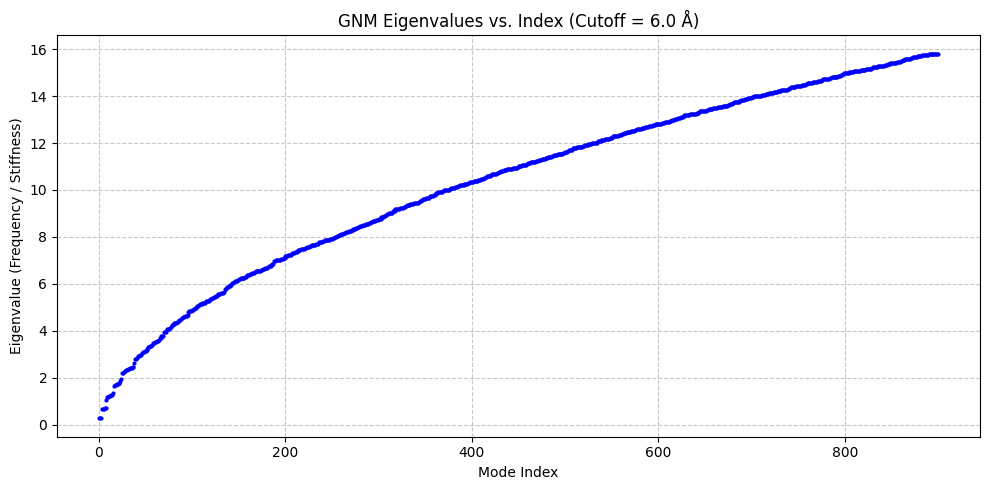

In [4]:
import matplotlib.pyplot as plt

# Ensure you run this after calculating the GNM modes 
# eigenvalues = gnm.getEigvals()

plt.figure(figsize=(10, 5))
plt.plot(eigenvalues, marker='o', markersize=2, linestyle='None', color='blue')
plt.title('GNM Eigenvalues vs. Index (Cutoff = 6.0 Å)')
plt.xlabel('Mode Index')
plt.ylabel('Eigenvalue (Frequency / Stiffness)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

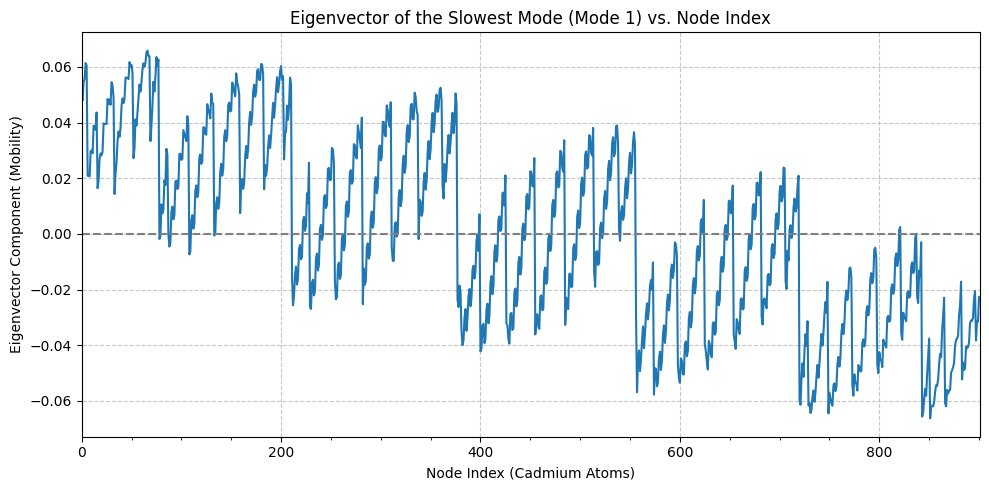

In [5]:
import matplotlib.pyplot as plt

# 7. Plot the eigenvector for the slowest non-zero eigenvalue (Mode 1)
# Note: In Python/ProDy, index 0 corresponds to the 1st mode.
plt.figure(figsize=(10, 5))
showMode(gnm[0])
plt.title('Eigenvector of the Slowest Mode (Mode 1) vs. Node Index')
plt.xlabel('Node Index (Cadmium Atoms)')
plt.ylabel('Eigenvector Component (Mobility)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

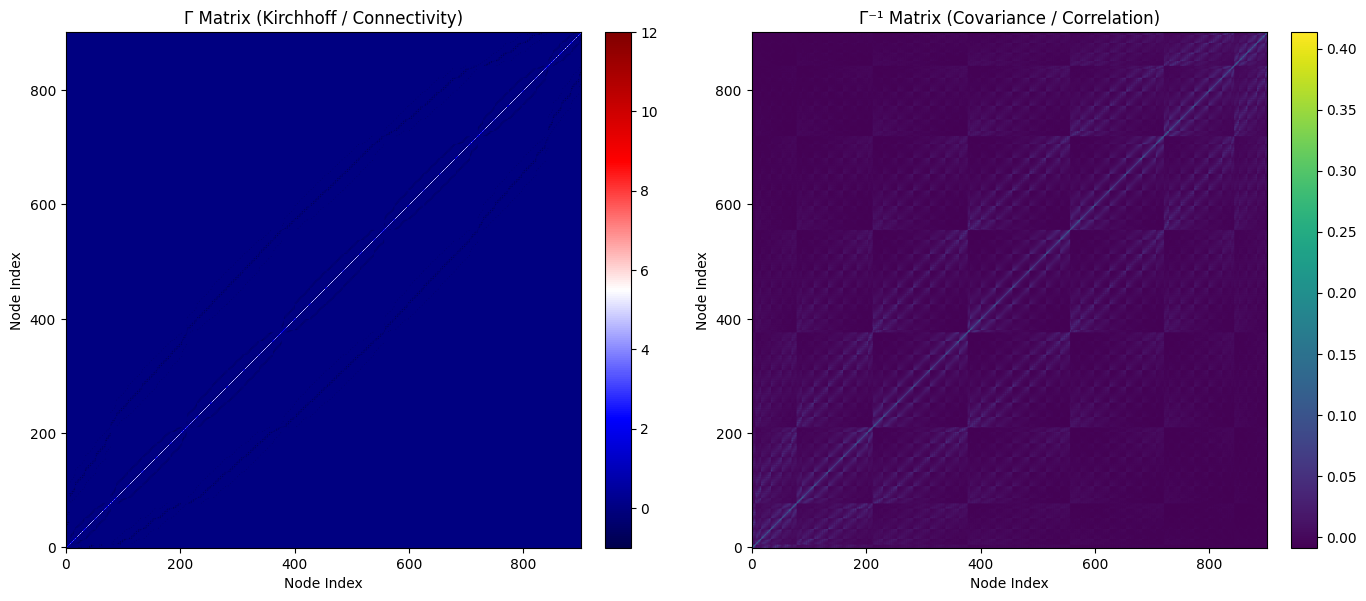

In [6]:
import matplotlib.pyplot as plt

# 8. Get the Gamma (Kirchhoff) matrix
gamma_matrix = gnm.getKirchhoff()

# 9. Get the Inverse Gamma (Covariance) matrix
# Note: ProDy calculates the pseudo-inverse automatically when you call calcModes()
gamma_inverse = gnm.getCovariance()

# 10. Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Gamma
im1 = axes[0].imshow(gamma_matrix, cmap='seismic', origin='lower')
axes[0].set_title('Γ Matrix (Kirchhoff / Connectivity)')
axes[0].set_xlabel('Node Index')
axes[0].set_ylabel('Node Index')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot Inverse Gamma
im2 = axes[1].imshow(gamma_inverse, cmap='viridis', origin='lower')
axes[1].set_title('Γ⁻¹ Matrix (Covariance / Correlation)')
axes[1].set_xlabel('Node Index')
axes[1].set_ylabel('Node Index')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


--- FRAGMENTATION TEST (Cutoff = 6.0 Å) ---
Expected non-zero modes for a stable 3D system: 2700
Calculated non-zero modes by ProDy: 2700
Excess zero eigenvalues (Fragmented chunks): 0


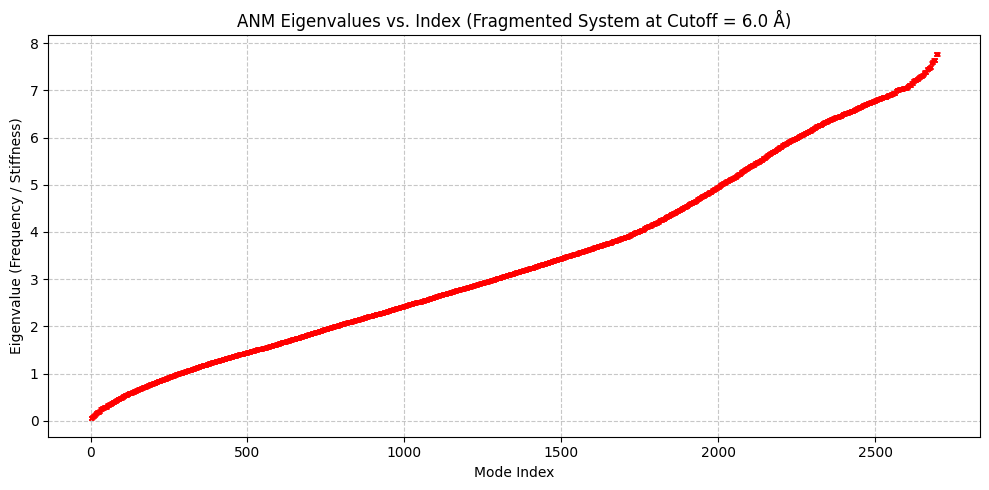

In [7]:
import matplotlib.pyplot as plt

# 1. Initialize a new failing ANM to test the 6.0 Å hypothesis
anm_6A = ANM('QDNP015_ANM_6A')

# 2. Build the Hessian matrix using the overly tight 6.0 Å cutoff
anm_6A.buildHessian(nodes, cutoff=6.0)

# 3. Calculate ALL modes
anm_6A.calcModes(n_modes='all')

# 4. Get the eigenvalues and calculate the fragmentation
eigenvals_6A = anm_6A.getEigvals()
expected_nonzero = (3 * nodes.numAtoms()) - 6
calculated_nonzero = len(eigenvals_6A)
excess_zeros = expected_nonzero - calculated_nonzero

print(f'\n--- FRAGMENTATION TEST (Cutoff = 6.0 Å) ---')
print(f'Expected non-zero modes for a stable 3D system: {expected_nonzero}')
print(f'Calculated non-zero modes by ProDy: {calculated_nonzero}')
print(f'Excess zero eigenvalues (Fragmented chunks): {excess_zeros}')

# 5. Plot the failing Eigenvalue vs. Mode Index
plt.figure(figsize=(10, 5))
plt.plot(eigenvals_6A, marker='x', markersize=3, linestyle='None', color='red')
plt.title('ANM Eigenvalues vs. Index (Fragmented System at Cutoff = 6.0 Å)')
plt.xlabel('Mode Index')
plt.ylabel('Eigenvalue (Frequency / Stiffness)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Number of calculated ANM eigenvalues: 2700


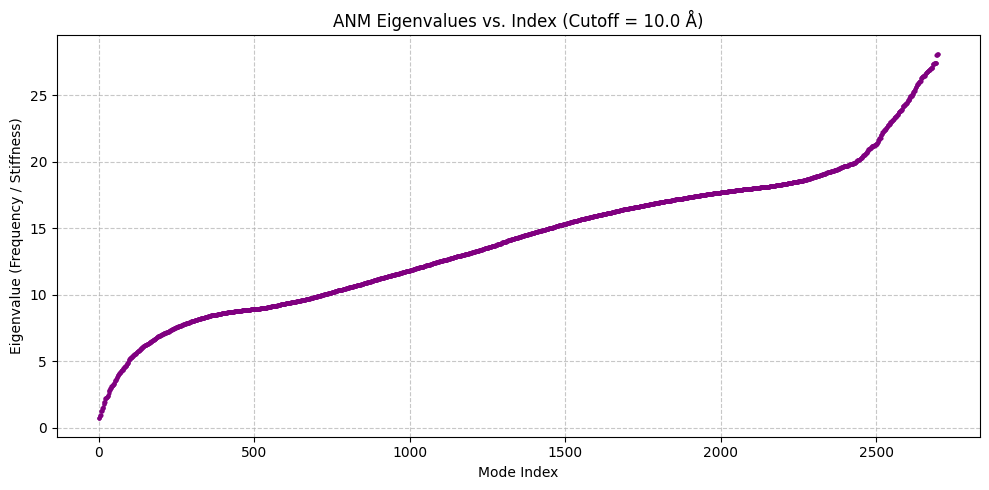

In [8]:
# 11. Initialize the ANM
anm = ANM('QDNP015_ANM')

# 12. Build the Hessian matrix using the new 10.0 Å cutoff
anm.buildHessian(nodes, cutoff=10.0)

# 13. Calculate ALL modes
anm.calcModes(n_modes='all')

# 14. Get and count the eigenvalues
anm_eigenvalues = anm.getEigvals()
print(f'\nNumber of calculated ANM eigenvalues: {len(anm_eigenvalues)}')

# 15. Plot Eigenvalue vs. Mode Index
plt.figure(figsize=(10, 5))
plt.plot(anm_eigenvalues, marker='o', markersize=2, linestyle='None', color='purple')
plt.title('ANM Eigenvalues vs. Index (Cutoff = 10.0 Å)')
plt.xlabel('Mode Index')
plt.ylabel('Eigenvalue (Frequency / Stiffness)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

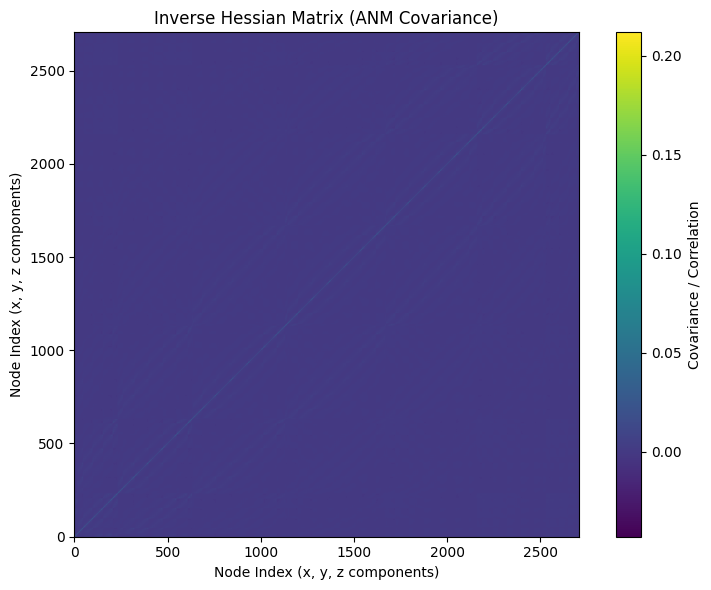

In [9]:
import matplotlib.pyplot as plt

# 16. Get the Inverse Hessian (Covariance) matrix from the ANM
# Note: ProDy automatically computes this when you run calcModes()
anm_covariance = anm.getCovariance()

# 17. Plot the Inverse Hessian Matrix
plt.figure(figsize=(8, 6))
im3 = plt.imshow(anm_covariance, cmap='viridis', origin='lower')
plt.title('Inverse Hessian Matrix (ANM Covariance)')
plt.xlabel('Node Index (x, y, z components)')
plt.ylabel('Node Index (x, y, z components)')
plt.colorbar(im3, label='Covariance / Correlation')
plt.tight_layout()
plt.show()

In [10]:
# 18. Generate the .nmd file to visualize the modes in VMD
# Note: We pass the ANM model and the Cadmium nodes we selected earlier
writeNMD('QDNP015_ANM_modes.nmd', anm, nodes)
print("Successfully generated QDNP015_ANM_modes.nmd!")

Successfully generated QDNP015_ANM_modes.nmd!


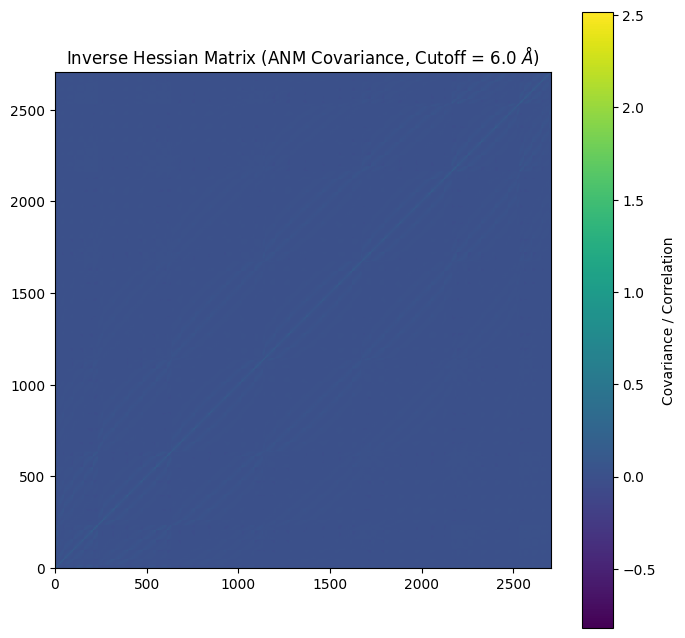

In [11]:
# ANM with 6.0 Angstrom cutoff
anm_6 = ANM('QDNP015_ANM_6')
anm_6.buildHessian(nodes, cutoff=6.0)
anm_6.calcModes(n_modes='all')

anm_covariance_6 = anm_6.getCovariance()

plt.figure(figsize=(8, 8))
im = plt.imshow(anm_covariance_6, cmap='viridis', origin='lower')
plt.title('Inverse Hessian Matrix (ANM Covariance, Cutoff = 6.0 $\\AA$)')
plt.colorbar(im, label='Covariance / Correlation')
plt.savefig('report/Figure8-2.png', bbox_inches='tight')
plt.show()